# 💰 AI-Powered Loan Approval & Credit Risk Analytics

**AICTE | IBM SkillsBuild — Data Analytics with AI Internship 2026 (BharatCares)**

**Workflow:** Data loading → Cleaning → Feature engineering → KPIs → EDA → Risk segmentation → ML model → Insights → Recommendations

> **Academic note:** This project demonstrates how data can *support* lending decisions. The model is not intended to approve or reject real borrowers on its own.

## 1. Setup & Imports

In [1]:
import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
os.makedirs("figures", exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=130, bbox_inches="tight")

RESULTS = {}   # everything the project report needs is collected here
print("Setup complete")

Setup complete

## 2. Load the Dataset

The notebook looks for the public Kaggle **Loan Approval Prediction Dataset** (`loan_approval_dataset.csv`, 4,269 rows) in the same folder.
If the file is not found, it generates a **schema-compatible synthetic dataset** so the notebook always runs end-to-end.
Both have identical columns, so no code changes are needed when you swap in the real file.

In [2]:
def generate_synthetic_loan_data(n=4269, seed=42):
    """Synthetic data with the same schema as the Kaggle 'Loan Approval Prediction Dataset' (amounts in INR)."""
    rng = np.random.default_rng(seed)
    r100k = lambda x: (np.round(x / 100000) * 100000).astype(int)

    income    = rng.integers(2, 100, n) * 100000
    ratio     = rng.uniform(1.0, 5.0, n)
    loan      = np.clip(r100k(income * ratio), 300000, 39500000)
    term      = rng.choice(np.arange(2, 21, 2), n)
    cibil     = rng.integers(300, 901, n)
    resid     = r100k(income * rng.uniform(0.2, 3.5, n))
    commer    = r100k(income * rng.uniform(0.0, 2.5, n))
    luxury    = r100k(income * rng.uniform(0.5, 4.0, n))
    bank      = r100k(income * rng.uniform(0.1, 1.5, n))
    educ      = rng.choice([" Graduate", " Not Graduate"], n)
    selfemp   = rng.choice([" No", " Yes"], n)
    depend    = rng.integers(0, 6, n)

    lti       = loan / income
    cover     = (resid + commer + luxury + bank) / loan
    z = ((cibil - 560) / 38.0) - 0.45 * (lti - 3.0) + 0.25 * np.clip(cover - 1.5, -1, 2) \
        + 0.15 * (educ == " Graduate") - 0.03 * (term - 11) / 3
    p = 1 / (1 + np.exp(-z))
    status = np.where(rng.random(n) < p, " Approved", " Rejected")

    return pd.DataFrame({
        "loan_id": np.arange(1, n + 1),
        " no_of_dependents": depend, " education": educ, " self_employed": selfemp,
        " income_annum": income, " loan_amount": loan, " loan_term": term, " cibil_score": cibil,
        " residential_assets_value": resid, " commercial_assets_value": commer,
        " luxury_assets_value": luxury, " bank_asset_value": bank, " loan_status": status})

REAL_PATH  = "loan_approval_dataset.csv"
SYNTH_PATH = "loan_approval_dataset_synthetic.csv"

if os.path.exists(REAL_PATH):
    raw = pd.read_csv(REAL_PATH);  DATA_SOURCE = "Kaggle: Loan Approval Prediction Dataset"
else:
    raw = generate_synthetic_loan_data(); raw.to_csv(SYNTH_PATH, index=False)
    DATA_SOURCE = "Synthetic dataset (schema-compatible with the Kaggle Loan Approval Prediction Dataset)"

RESULTS["data_source"] = DATA_SOURCE
print("Data source:", DATA_SOURCE)
print("Shape:", raw.shape)
raw.head()

Data source: Synthetic dataset (schema-compatible with the Kaggle Loan Approval Prediction Dataset)
Shape: (4269, 13)

   loan_id   no_of_dependents  ...  bank_asset_value  loan_status
0        1                  2  ...            200000     Approved
1        2                  2  ...          10300000     Rejected
2        3                  5  ...           9600000     Rejected
3        4                  5  ...           2200000     Rejected
4        5                  5  ...           3300000     Rejected

[5 rows x 13 columns]

## 3. Data Understanding

In [3]:
print(raw.dtypes.to_string())
print()
print("Raw column names:", list(raw.columns))

loan_id                      int64
 no_of_dependents            int64
 education                     str
 self_employed                 str
 income_annum                int64
 loan_amount                 int64
 loan_term                   int64
 cibil_score                 int64
 residential_assets_value    int64
 commercial_assets_value     int64
 luxury_assets_value         int64
 bank_asset_value            int64
 loan_status                   str

Raw column names: ['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']

In [4]:
raw.describe().T.round(1)

                            count        mean  ...         75%         max
loan_id                    4269.0      2135.0  ...      3202.0      4269.0
 no_of_dependents          4269.0         2.5  ...         4.0         5.0
 income_annum              4269.0   5036120.9  ...   7500000.0   9900000.0
 loan_amount               4269.0  14785031.6  ...  21400000.0  39500000.0
 loan_term                 4269.0        11.0  ...        16.0        20.0
 cibil_score               4269.0       595.8  ...       744.0       900.0
 residential_assets_value  4269.0   9322300.3  ...  14000000.0  34600000.0
 commercial_assets_value   4269.0   6326587.0  ...   9700000.0  24600000.0
 luxury_assets_value       4269.0  11472499.4  ...  16800000.0  39600000.0
 bank_asset_value          4269.0   4031459.4  ...   5900000.0  14500000.0

[10 rows x 8 columns]

### Column dictionary

| Column | Meaning | Type |
|---|---|---|
| `loan_id` | Unique application ID | ID |
| `no_of_dependents` | Number of dependents of the applicant | Numeric |
| `education` | Graduate / Not Graduate | Categorical |
| `self_employed` | Whether the applicant is self-employed | Categorical |
| `income_annum` | Annual income (INR) | Numeric |
| `loan_amount` | Loan amount requested (INR) | Numeric |
| `loan_term` | Loan tenure in years | Numeric |
| `cibil_score` | Credit score (300–900) | Numeric |
| `residential/commercial/luxury_assets_value`, `bank_asset_value` | Value of applicant's assets (INR) | Numeric |
| `loan_status` | **Target** — Approved / Rejected | Categorical |

## 4. Data Cleaning & Quality Checks

In [5]:
df = raw.copy()

# 4.1 Standardise column names and text values (raw files often carry stray spaces)
df.columns = df.columns.str.strip().str.lower()
for c in df.select_dtypes(include=["object", "string"]).columns:
    df[c] = df[c].str.strip()

# 4.2 Duplicates
dup_rows = int(df.duplicated().sum())
dup_ids  = int(df["loan_id"].duplicated().sum())
df = df.drop_duplicates()

# 4.3 Missing values
missing = df.isna().sum()
print("Duplicate rows:", dup_rows, "| Duplicate loan IDs:", dup_ids)
print("Missing values per column:\n", missing[missing > 0] if missing.sum() else "None")
num_cols = df.select_dtypes(include="number").columns.drop("loan_id")
cat_cols = df.select_dtypes(exclude="number").columns
for c in num_cols:
    if df[c].isna().any(): df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    if df[c].isna().any(): df[c] = df[c].fillna(df[c].mode()[0])

# 4.4 Invalid values: asset values cannot be negative
asset_cols = [c for c in df.columns if "asset" in c]
neg_count = int((df[asset_cols] < 0).sum().sum())
df[asset_cols] = df[asset_cols].clip(lower=0)

# 4.5 Value-range validation
assert df["cibil_score"].between(300, 900).all(), "CIBIL score outside 300-900"
assert (df["income_annum"] > 0).all() and (df["loan_amount"] > 0).all()

# 4.6 Outliers (IQR) - flagged, NOT removed: high-income / high-loan applicants are genuine
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    return int(((s < q1 - 1.5 * i) | (s > q3 + 1.5 * i)).sum())
outliers = {c: iqr_outliers(df[c]) for c in ["income_annum", "loan_amount", "cibil_score"]}

print("Negative asset values fixed:", neg_count)
print("IQR outliers flagged (kept):", outliers)
print("Clean shape:", df.shape)

RESULTS["cleaning"] = {"rows_raw": int(len(raw)), "rows_clean": int(len(df)), "duplicates": dup_rows,
                       "missing_total": int(missing.sum()), "negative_assets_fixed": neg_count, "outliers": outliers}

Duplicate rows: 0 | Duplicate loan IDs: 0
Missing values per column:
 None
Negative asset values fixed: 0
IQR outliers flagged (kept): {'income_annum': 0, 'loan_amount': 0, 'cibil_score': 0}
Clean shape: (4269, 13)

## 5. Feature Engineering

In [6]:
df["approved"] = (df["loan_status"] == "Approved").astype(int)

df["total_assets"]   = df[asset_cols].sum(axis=1)
df["loan_to_income"] = df["loan_amount"] / df["income_annum"]        # how many years of income the loan represents
df["asset_coverage"] = df["total_assets"] / df["loan_amount"]        # assets held per rupee borrowed

df["cibil_band"]  = pd.cut(df["cibil_score"], [299, 549, 649, 749, 900],
                           labels=["Poor (300-549)", "Fair (550-649)", "Good (650-749)", "Excellent (750-900)"])
df["income_band"] = pd.qcut(df["income_annum"], 4, labels=["Low", "Lower-Mid", "Upper-Mid", "High"])
df["lti_band"]    = pd.cut(df["loan_to_income"], [0, 2, 3, 4, 100], labels=["<=2x", "2-3x", "3-4x", ">4x"])
df["loan_size_band"] = pd.qcut(df["loan_amount"], 4, labels=["Small", "Medium", "Large", "Very Large"])

df[["income_annum", "loan_amount", "loan_to_income", "asset_coverage", "cibil_band", "income_band", "approved"]].head()

   income_annum  loan_amount  ...  income_band  approved
0       1000000      3100000  ...          Low         1
1       7700000     17400000  ...         High         0
2       6600000     27000000  ...    Upper-Mid         0
3       4500000     18300000  ...    Lower-Mid         0
4       4400000     19300000  ...    Lower-Mid         0

[5 rows x 7 columns]

## 6. Key Performance Indicators (KPIs)

In [7]:
kpi = {
    "Total Applications":      len(df),
    "Approval Rate (%)":       round(df["approved"].mean() * 100, 1),
    "Rejection Rate (%)":      round((1 - df["approved"].mean()) * 100, 1),
    "Average Loan Amount (INR)": round(df["loan_amount"].mean()),
    "Average Annual Income (INR)": round(df["income_annum"].mean()),
    "Average CIBIL Score":     round(df["cibil_score"].mean(), 1),
    "Low-Credit (CIBIL<550) Applicants (%)": round((df["cibil_score"] < 550).mean() * 100, 1),
    "Approved Loan Value (INR Cr)": round(df.loc[df.approved == 1, "loan_amount"].sum() / 1e7, 1),
}
RESULTS["kpi"] = {k: float(v) for k, v in kpi.items()}
pd.DataFrame(kpi.items(), columns=["KPI", "Value"]).set_index("KPI")

                                            Value
KPI                                              
Total Applications                         4269.0
Approval Rate (%)                            57.5
Rejection Rate (%)                           42.5
Average Loan Amount (INR)              14785032.0
Average Annual Income (INR)             5036121.0
Average CIBIL Score                         595.8
Low-Credit (CIBIL<550) Applicants (%)        42.4
Approved Loan Value (INR Cr)               3566.7

## 7. Exploratory Data Analysis

### 7.1 Approval vs. rejection

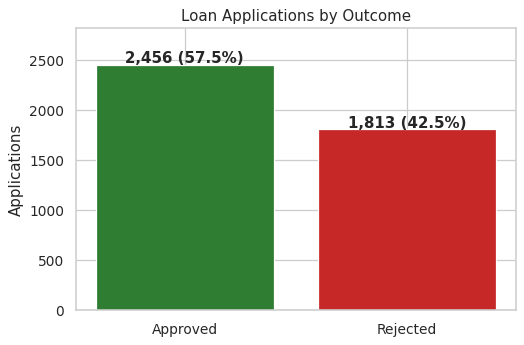

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["loan_status"].value_counts()
bars = ax.bar(counts.index, counts.values, color=["#2E7D32", "#C62828"])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 20, f"{v:,} ({v/len(df):.1%})", ha="center", fontweight="bold")
ax.set_title("Loan Applications by Outcome"); ax.set_ylabel("Applications"); ax.set_ylim(0, counts.max() * 1.15)
savefig("01_approval_distribution"); plt.show()

### 7.2 Income and loan-amount distributions

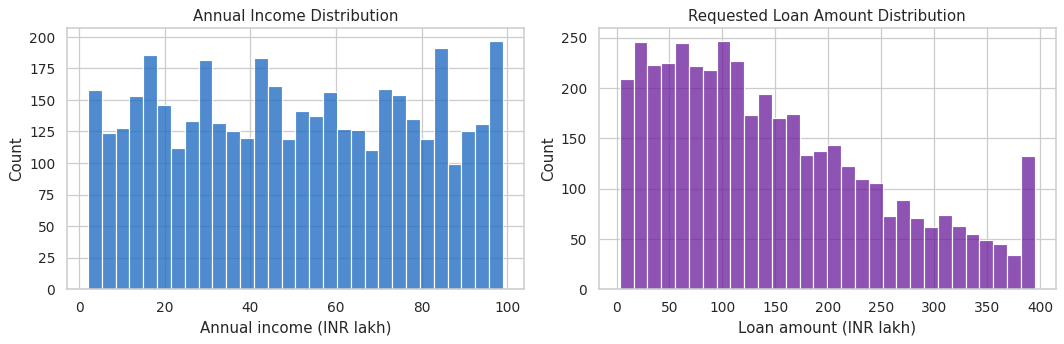

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["income_annum"] / 1e5, bins=30, ax=axes[0], color="#1565C0")
axes[0].set_title("Annual Income Distribution"); axes[0].set_xlabel("Annual income (INR lakh)")
sns.histplot(df["loan_amount"] / 1e5, bins=30, ax=axes[1], color="#6A1B9A")
axes[1].set_title("Requested Loan Amount Distribution"); axes[1].set_xlabel("Loan amount (INR lakh)")
savefig("02_income_loan_distribution"); plt.show()

### 7.3 Credit score — the strongest signal?

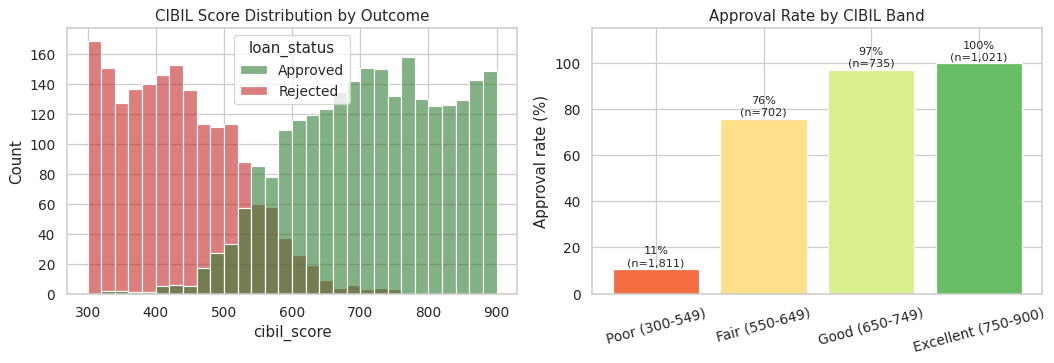

                         mean  count
cibil_band                          
Poor (300-549)       0.106571   1811
Fair (550-649)       0.756410    702
Good (650-749)       0.970068    735
Excellent (750-900)  0.998041   1021

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.histplot(data=df, x="cibil_score", hue="loan_status", bins=30, multiple="layer", alpha=.6,
             palette={"Approved": "#2E7D32", "Rejected": "#C62828"}, ax=axes[0])
axes[0].set_title("CIBIL Score Distribution by Outcome")

cb = df.groupby("cibil_band", observed=True)["approved"].agg(["mean", "count"])
bars = axes[1].bar(cb.index.astype(str), cb["mean"] * 100, color=sns.color_palette("RdYlGn", 4))
for b, (m, c) in zip(bars, cb.values):
    axes[1].text(b.get_x() + b.get_width()/2, m*100 + 1.5, f"{m:.0%}\n(n={int(c):,})", ha="center", fontsize=9)
axes[1].set_ylim(0, 115); axes[1].set_ylabel("Approval rate (%)"); axes[1].set_title("Approval Rate by CIBIL Band")
axes[1].tick_params(axis="x", labelrotation=15)
savefig("03_cibil_analysis"); plt.show()
RESULTS["approval_by_cibil"] = {str(k): round(float(v) * 100, 1) for k, v in cb["mean"].items()}
RESULTS["count_by_cibil"] = {str(k): int(v) for k, v in cb["count"].items()}
cb

### 7.4 Applicant profile vs. approval

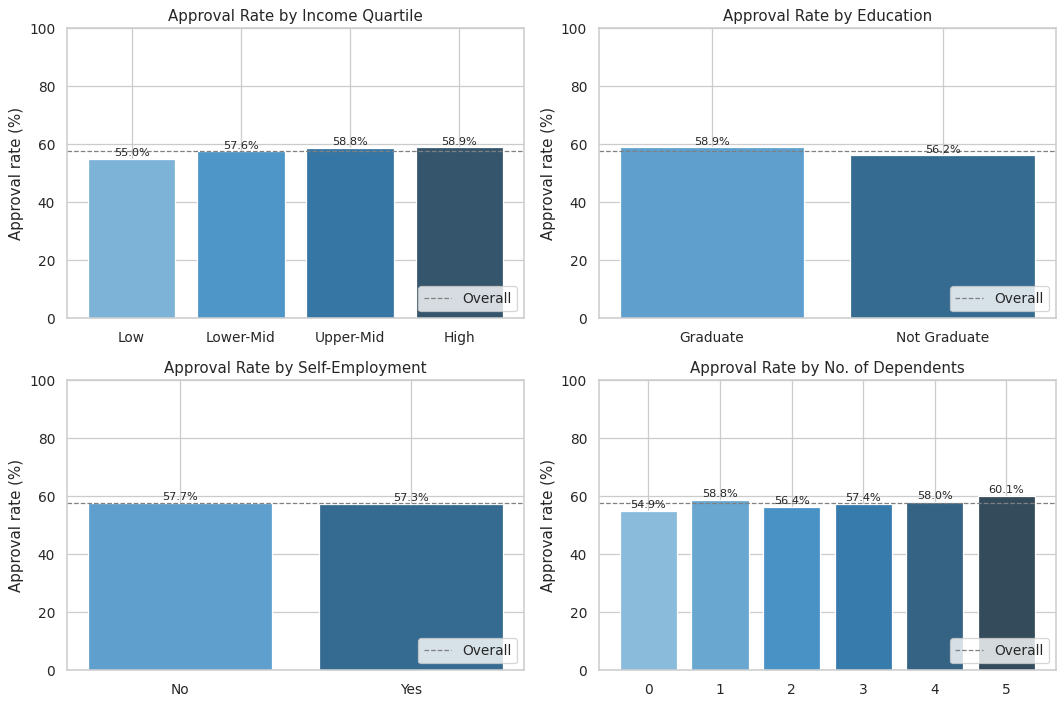

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
def rate_plot(col, ax, title, order=None):
    r = df.groupby(col, observed=True)["approved"].mean().mul(100)
    if order: r = r.reindex(order)
    b = ax.bar(r.index.astype(str), r.values, color=sns.color_palette("Blues_d", len(r)))
    for bar, v in zip(b, r.values): ax.text(bar.get_x()+bar.get_width()/2, v+1, f"{v:.1f}%", ha="center", fontsize=9)
    ax.axhline(df["approved"].mean()*100, color="grey", ls="--", lw=1, label="Overall")
    ax.set_ylim(0, 100); ax.set_title(title); ax.set_ylabel("Approval rate (%)"); ax.legend(loc="lower right")
    return r
r_inc = rate_plot("income_band", axes[0,0], "Approval Rate by Income Quartile")
r_edu = rate_plot("education", axes[0,1], "Approval Rate by Education")
r_emp = rate_plot("self_employed", axes[1,0], "Approval Rate by Self-Employment")
r_dep = rate_plot("no_of_dependents", axes[1,1], "Approval Rate by No. of Dependents")
savefig("04_applicant_profile"); plt.show()
RESULTS["approval_by_income"] = {str(k): round(float(v), 1) for k, v in r_inc.items()}
RESULTS["approval_by_education"] = {str(k): round(float(v), 1) for k, v in r_edu.items()}
RESULTS["approval_by_selfemp"] = {str(k): round(float(v), 1) for k, v in r_emp.items()}
RESULTS["approval_by_dependents"] = {str(k): round(float(v), 1) for k, v in r_dep.items()}

### 7.5 Loan size, tenure and affordability vs. approval

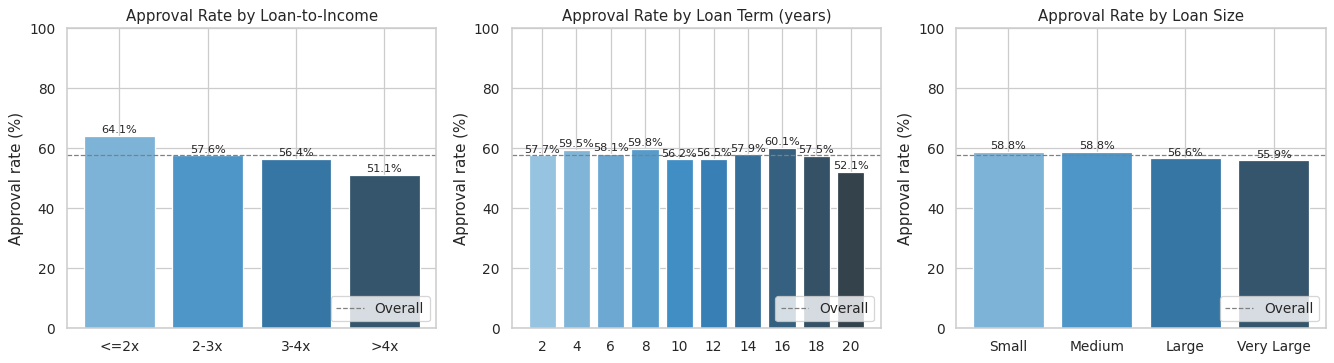

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
r_lti = rate_plot("lti_band", axes[0], "Approval Rate by Loan-to-Income")
r_term = rate_plot("loan_term", axes[1], "Approval Rate by Loan Term (years)")
r_size = rate_plot("loan_size_band", axes[2], "Approval Rate by Loan Size")
savefig("05_loan_characteristics"); plt.show()
RESULTS["approval_by_lti"] = {str(k): round(float(v), 1) for k, v in r_lti.items()}
RESULTS["approval_by_size"] = {str(k): round(float(v), 1) for k, v in r_size.items()}

### 7.6 Correlation heatmap

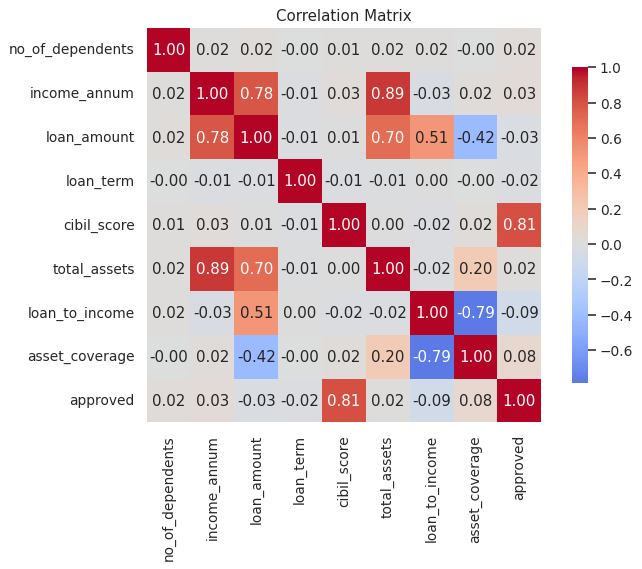

cibil_score         0.806
loan_to_income     -0.095
asset_coverage      0.081
income_annum        0.032
loan_amount        -0.030
no_of_dependents    0.025
loan_term          -0.021
total_assets        0.015
Name: approved, dtype: float64

In [13]:
num_for_corr = ["no_of_dependents", "income_annum", "loan_amount", "loan_term", "cibil_score",
                "total_assets", "loan_to_income", "asset_coverage", "approved"]
corr = df[num_for_corr].corr()
plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix")
savefig("06_correlation"); plt.show()
RESULTS["corr_with_approval"] = {k: round(float(v), 3) for k, v in corr["approved"].drop("approved").sort_values(key=abs, ascending=False).items()}
corr["approved"].drop("approved").sort_values(key=abs, ascending=False).round(3)

### 7.7 Credit score × affordability (two-factor view)

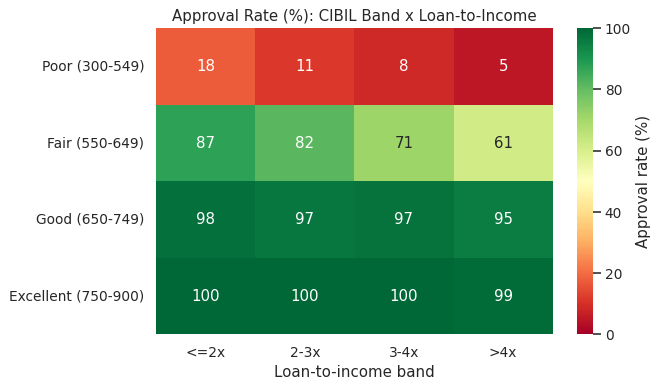

In [14]:
pivot = df.pivot_table(index="cibil_band", columns="lti_band", values="approved", aggfunc="mean", observed=True) * 100
plt.figure(figsize=(7.5, 4.5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100, cbar_kws={"label": "Approval rate (%)"})
plt.title("Approval Rate (%): CIBIL Band x Loan-to-Income"); plt.ylabel(""); plt.xlabel("Loan-to-income band")
savefig("07_cibil_lti_heatmap"); plt.show()

## 8. Risk Segmentation

The dataset has no repayment/default column, so a true default-risk model is not possible. Instead we build a transparent **application risk score** from three lender-relevant factors:

| Factor | Points |
|---|---|
| CIBIL score | <550 → 3, 550-649 → 2, 650-749 → 1, ≥750 → 0 |
| Loan-to-income | >4x → 2, 3-4x → 1, else 0 |
| Asset coverage < 0.5 | +1 |

**Tier:** Low (0-1 pts) · Medium (2-3 pts) · High (4+ pts)

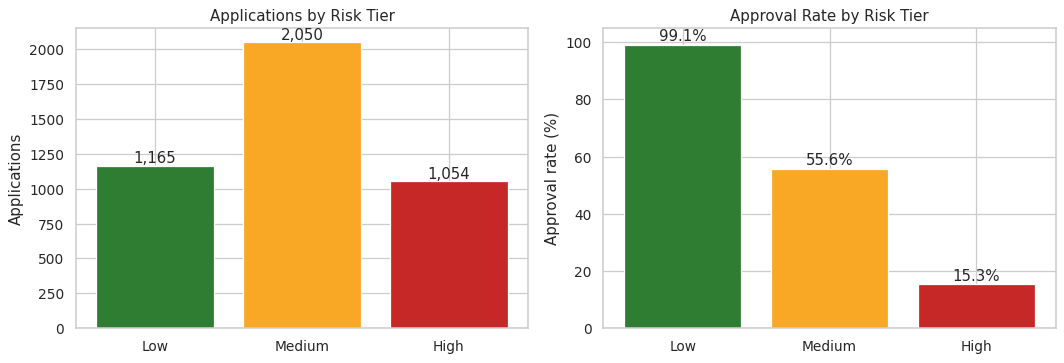

           applications  share_pct  ...  total_requested_cr  approved_value_cr
risk_tier                           ...                                       
Low                1165       27.3  ...              1375.9             1364.4
Medium             2050       48.0  ...              2827.7             1845.5
High               1054       24.7  ...              2108.2              356.7

[3 rows x 6 columns]

In [15]:
cibil_pts = np.select([df.cibil_score < 550, df.cibil_score < 650, df.cibil_score < 750], [3, 2, 1], 0)
lti_pts   = np.select([df.loan_to_income > 4, df.loan_to_income > 3], [2, 1], 0)
cov_pts   = (df.asset_coverage < 0.5).astype(int)
df["risk_points"] = cibil_pts + lti_pts + cov_pts
df["risk_tier"] = pd.cut(df["risk_points"], [-1, 1, 3, 10], labels=["Low", "Medium", "High"])

tier = df.groupby("risk_tier", observed=True).agg(
    applications=("approved", "size"),
    share_pct=("approved", lambda s: len(s) / len(df) * 100),
    approval_rate_pct=("approved", lambda s: s.mean() * 100),
    avg_loan_lakh=("loan_amount", lambda s: s.mean() / 1e5),
    total_requested_cr=("loan_amount", lambda s: s.sum() / 1e7)).round(1)
tier["approved_value_cr"] = df[df.approved == 1].groupby("risk_tier", observed=True)["loan_amount"].sum().div(1e7).round(1)
RESULTS["risk_tiers"] = tier.reset_index().astype({"risk_tier": str}).to_dict(orient="records")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
cols = {"Low": "#2E7D32", "Medium": "#F9A825", "High": "#C62828"}
axes[0].bar(tier.index.astype(str), tier["applications"], color=[cols[t] for t in tier.index])
axes[0].set_title("Applications by Risk Tier"); axes[0].set_ylabel("Applications")
for i, v in enumerate(tier["applications"]): axes[0].text(i, v + 20, f"{v:,}", ha="center")
axes[1].bar(tier.index.astype(str), tier["approval_rate_pct"], color=[cols[t] for t in tier.index])
axes[1].set_title("Approval Rate by Risk Tier"); axes[1].set_ylabel("Approval rate (%)"); axes[1].set_ylim(0, 105)
for i, v in enumerate(tier["approval_rate_pct"]): axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center")
savefig("08_risk_tiers"); plt.show()
tier

## 9. AI / Machine-Learning Model — Loan Approval Prediction

In [16]:
df["education_grad"] = (df["education"] == "Graduate").astype(int)
df["self_emp_yes"]   = (df["self_employed"] == "Yes").astype(int)

FEATURES = ["no_of_dependents", "income_annum", "loan_amount", "loan_term", "cibil_score",
            "residential_assets_value", "commercial_assets_value", "luxury_assets_value", "bank_asset_value",
            "loan_to_income", "asset_coverage", "education_grad", "self_emp_yes"]
X, y = df[FEATURES], df["approved"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape}  Test: {X_test.shape}  | Approved share train/test: {y_train.mean():.3f} / {y_test.mean():.3f}")

Train: (3415, 13)  Test: (854, 13)  | Approved share train/test: 0.575 / 0.575

In [17]:
models = {
    "Logistic Regression": Pipeline([("scale", StandardScaler()), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows, fitted = [], {}
for name, m in models.items():
    cv_auc = cross_val_score(m, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    m.fit(X_train, y_train); fitted[name] = m
    pred, proba = m.predict(X_test), m.predict_proba(X_test)[:, 1]
    rows.append({"Model": name, "CV ROC-AUC": cv_auc, "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred), "Recall": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred), "Test ROC-AUC": roc_auc_score(y_test, proba)})
results = pd.DataFrame(rows).set_index("Model").round(4)
results

                     CV ROC-AUC  Accuracy  ...      F1  Test ROC-AUC
Model                                      ...                      
Logistic Regression      0.9718    0.9251  ...  0.9337        0.9790
Decision Tree            0.9627    0.9239  ...  0.9332        0.9769
Random Forest            0.9654    0.9262  ...  0.9358        0.9741

[3 rows x 6 columns]

### Hyper-parameter tuning of the best tree-based model

In [18]:
grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                    {"n_estimators": [200, 400], "max_depth": [4, 6, 8, 12], "min_samples_leaf": [2, 5, 10]},
                    cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_, "| CV ROC-AUC:", round(grid.best_score_, 4))
best = grid.best_estimator_
fitted["Random Forest (Tuned)"] = best
pred, proba = best.predict(X_test), best.predict_proba(X_test)[:, 1]
results.loc["Random Forest (Tuned)"] = [grid.best_score_, accuracy_score(y_test, pred), precision_score(y_test, pred),
                                        recall_score(y_test, pred), f1_score(y_test, pred), roc_auc_score(y_test, proba)]
results = results.round(4)
RESULTS["model_results"] = results.reset_index().to_dict(orient="records")
RESULTS["best_params"] = {k: int(v) for k, v in grid.best_params_.items()}
results

Best parameters: {'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 400} | CV ROC-AUC: 0.9662

                       CV ROC-AUC  Accuracy  ...      F1  Test ROC-AUC
Model                                        ...                      
Logistic Regression        0.9718    0.9251  ...  0.9337        0.9790
Decision Tree              0.9627    0.9239  ...  0.9332        0.9769
Random Forest              0.9654    0.9262  ...  0.9358        0.9741
Random Forest (Tuned)      0.9662    0.9239  ...  0.9341        0.9743

[4 rows x 6 columns]

### Confusion matrix & ROC curves

              precision    recall  f1-score   support

    Rejected       0.92      0.90      0.91       363
    Approved       0.93      0.94      0.93       491

    accuracy                           0.92       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.92      0.92      0.92       854

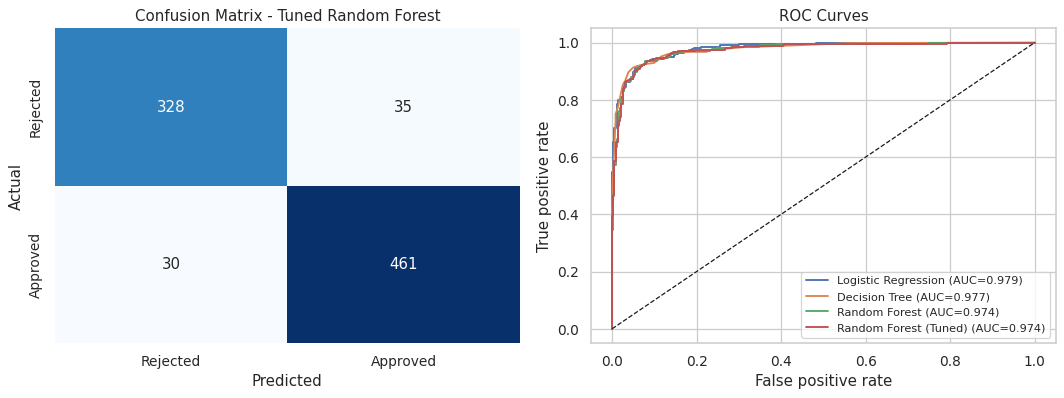

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
axes[0].set_title("Confusion Matrix - Tuned Random Forest"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
for name, m in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:, 1])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1); axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC Curves"); axes[1].legend(loc="lower right", fontsize=9)
savefig("09_model_evaluation"); plt.show()
tn, fp, fn, tp = cm.ravel()
RESULTS["confusion"] = {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}
print(classification_report(y_test, pred, target_names=["Rejected", "Approved"]))

### What drives the model? (permutation importance + logistic-regression odds)

Odds ratio per +1 standard deviation (Logistic Regression):

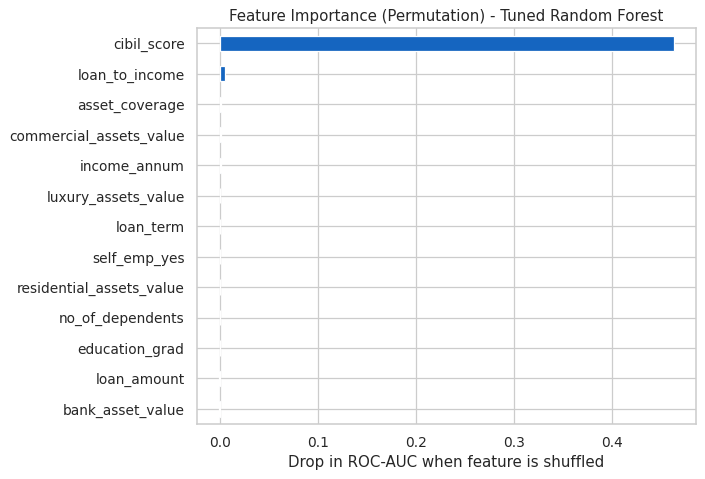

cibil_score                 83.54
asset_coverage               1.23
loan_amount                  1.15
no_of_dependents             1.10
education_grad               1.09
self_emp_yes                 1.07
commercial_assets_value      1.07
bank_asset_value             0.98
residential_assets_value     0.97
income_annum                 0.94
loan_term                    0.90
luxury_assets_value          0.86
loan_to_income               0.61
dtype: float64

In [20]:
pi = permutation_importance(best, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
plt.figure(figsize=(8, 5.5))
imp.plot.barh(color="#1565C0"); plt.xlabel("Drop in ROC-AUC when feature is shuffled")
plt.title("Feature Importance (Permutation) - Tuned Random Forest")
savefig("10_feature_importance"); plt.show()
RESULTS["importance"] = {k: round(float(v), 4) for k, v in imp.sort_values(ascending=False).items()}

lr = fitted["Logistic Regression"].named_steps["clf"]
odds = pd.Series(np.exp(lr.coef_[0]), index=FEATURES).sort_values(ascending=False).round(2)
RESULTS["odds_ratio_top"] = {k: float(v) for k, v in odds.head(4).items()}
print("Odds ratio per +1 standard deviation (Logistic Regression):"); odds

### Predicted approval probability vs. actual outcome (calibration check)

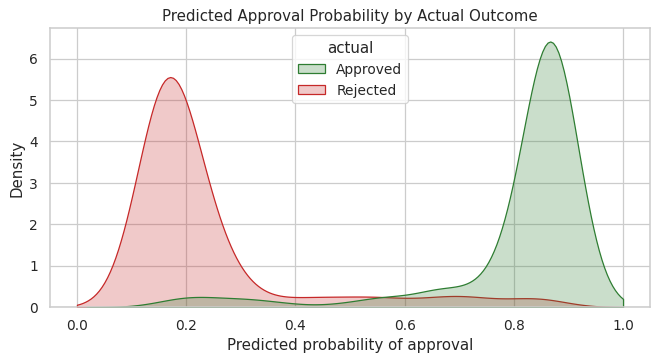

         applications  actual_approval_rate
band                                       
0-20%             244                 0.025
20-40%            102                 0.206
40-60%             33                 0.424
60-80%             70                 0.771
80-100%           405                 0.978

In [21]:
cal = pd.DataFrame({"proba": proba, "actual": y_test.values})
cal["band"] = pd.cut(cal["proba"], [0, .2, .4, .6, .8, 1.0], include_lowest=True,
                     labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"])
cal_t = cal.groupby("band", observed=True).agg(applications=("actual", "size"), actual_approval_rate=("actual", "mean")).round(3)
RESULTS["calibration"] = cal_t.reset_index().astype({"band": str}).to_dict(orient="records")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.kdeplot(data=cal, x="proba", hue=cal["actual"].map({1: "Approved", 0: "Rejected"}), fill=True, common_norm=False,
            palette={"Approved": "#2E7D32", "Rejected": "#C62828"}, ax=ax, clip=(0, 1))
ax.set_title("Predicted Approval Probability by Actual Outcome"); ax.set_xlabel("Predicted probability of approval")
savefig("11_probability_distribution"); plt.show()
cal_t

In [22]:
# Practical use: score a single hypothetical applicant
sample = pd.DataFrame([{"no_of_dependents": 2, "income_annum": 6_000_000, "loan_amount": 15_000_000, "loan_term": 12, "cibil_score": 720,
                        "residential_assets_value": 8_000_000, "commercial_assets_value": 2_000_000, "luxury_assets_value": 9_000_000,
                        "bank_asset_value": 3_000_000, "loan_to_income": 2.5, "asset_coverage": 22_000_000 / 15_000_000,
                        "education_grad": 1, "self_emp_yes": 0}])
print(f"Estimated approval probability for sample applicant: {best.predict_proba(sample[FEATURES])[0, 1]:.1%}")

Estimated approval probability for sample applicant: 88.0%

## 10. Automated Insight Summary

In [23]:
top = list(RESULTS["importance"].items())[:3]
ac = RESULTS["approval_by_cibil"]; cnt = RESULTS["count_by_cibil"]
best_row = results.loc["Random Forest (Tuned)"]
tiers = {t["risk_tier"]: t for t in RESULTS["risk_tiers"]}
inc = RESULTS["approval_by_income"]; edu = RESULTS["approval_by_education"]; emp = RESULTS["approval_by_selfemp"]

print("KEY FINDINGS")
print(f"1. Overall approval rate is {kpi['Approval Rate (%)']}% across {kpi['Total Applications']:,} applications.")
print(f"2. Credit score dominates: approval rate goes {' -> '.join(f'{v}%' for v in ac.values())} from Poor to Excellent CIBIL band.")
print(f"3. Top model drivers: {', '.join(f'{k} ({v})' for k, v in top)}.")
print(f"4. Income quartiles show approval of {inc['Low']}% (Low) vs {inc['High']}% (High); education gap: {edu.get('Graduate')}% vs {edu.get('Not Graduate')}%; self-employed gap: {emp.get('No')}% vs {emp.get('Yes')}%.")
print(f"5. Tuned Random Forest: accuracy {best_row['Accuracy']:.1%}, F1 {best_row['F1']:.3f}, ROC-AUC {best_row['Test ROC-AUC']:.3f}.")
print(f"6. Risk tiers: High = {tiers['High']['share_pct']}% of applications (approval {tiers['High']['approval_rate_pct']}%), Low = {tiers['Low']['share_pct']}% (approval {tiers['Low']['approval_rate_pct']}%).")

KEY FINDINGS
1. Overall approval rate is 57.5% across 4,269 applications.
2. Credit score dominates: approval rate goes 10.7% -> 75.6% -> 97.0% -> 99.8% from Poor to Excellent CIBIL band.
3. Top model drivers: cibil_score (0.4634), loan_to_income (0.0058), asset_coverage (0.0011).
4. Income quartiles show approval of 55.0% (Low) vs 58.9% (High); education gap: 58.9% vs 56.2%; self-employed gap: 57.7% vs 57.3%.
5. Tuned Random Forest: accuracy 92.4%, F1 0.934, ROC-AUC 0.974.
6. Risk tiers: High = 24.7% of applications (approval 15.3%), Low = 27.3% (approval 99.1%).

## 11. Risks, Opportunities & Recommended Actions

**Risks to monitor**
- **Credit-score dependence** — decisions hinge heavily on one bureau score; errors or thin-file applicants can be unfairly excluded.
- **Over-leveraged requests** — applications with a high loan-to-income ratio and weak asset cover are the riskiest segment.
- **Model risk** — the model reproduces historical decisions (including any historical bias); it does not measure repayment behaviour.
- **Borderline zone** — applicants near the approval threshold (Fair CIBIL band) are where manual review adds the most value.

**Opportunities**
- **Fair / borderline applicants with strong assets** — candidates for secured lending or a co-applicant/guarantor structure.
- **Fast-track Low-tier applicants** — high-confidence approvals can be processed with minimal manual effort.
- **Pre-screening** — score applications before human review to prioritise the queue.

**Recommended actions**
1. Use the risk-tier and predicted-probability score for **triage**, with human sign-off for borderline cases.
2. Offer **pre-application guidance** (e.g., how to improve credit score, a right-sized loan amount) to applicants likely to be rejected.
3. Set **loan-to-income guardrails** (e.g., manual review above 4x income).
4. **Audit** approval rates across education/self-employment/dependents groups regularly for fairness.
5. Collect **repayment / default data** to move from approval prediction to true credit-risk modelling.

## 12. Save Results

In [24]:
df.to_csv("loan_data_cleaned.csv", index=False)
with open("results_summary.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=str)
print("Saved: loan_data_cleaned.csv, results_summary.json, figures/*.png")

Saved: loan_data_cleaned.csv, results_summary.json, figures/*.png

## 13. Conclusion

The project took loan-application data through cleaning, feature engineering, KPI reporting, visual EDA, risk segmentation and machine-learning modelling.
The analysis identifies credit score and affordability (loan-to-income, asset cover) as the main levers behind approval, and a tuned Random Forest predicts historical outcomes with high accuracy.
The results are intended as **decision support** — a triage and insight tool — not a replacement for human credit judgement.